# Metrics Evaluation

This notebook computes quantitative evaluation metrics for all experiments:

- SSIM
- LPIPS
- CLIP Score
- Runtime

for dissertation evaluation .

In [69]:
!pip -q install scikit-image lpips transformers pillow pandas matplotlib

In [70]:
import os
import re
import torch
import lpips
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from PIL import Image
from skimage.metrics import structural_similarity as ssim
from transformers import CLIPProcessor, CLIPModel

In [71]:
repo_dir = "/content/image-data-generation"

experiments = {
    "baseline_vs_controlnet": f"{repo_dir}/results/baseline_vs_controlnet",
    "controlnet_vs_ipadapter": f"{repo_dir}/results/controlnet_vs_ipadapter",
    "full_pipeline_ablation": f"{repo_dir}/results/full_pipeline_ablation",
}

metrics_dir = f"{repo_dir}/results/metrics"
os.makedirs(metrics_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [72]:
def load_image(path, size=(512, 512)):
    return Image.open(path).convert("RGB").resize(size)

def image_to_numpy(img):
    return np.array(img)

def calculate_ssim(original, generated):
    original_np = image_to_numpy(original)
    generated_np = image_to_numpy(generated)

    return ssim(original_np,generated_np,channel_axis=2,data_range=255)

def read_runtime(metadata_path, label):
    if not os.path.exists(metadata_path):
        return None

    with open(metadata_path, "r") as f:
        text = f.read()

    patterns = {
        "baseline_sd": r"Baseline runtime: ([0-9.]+)",
        "controlnet_depth": r"ControlNet runtime: ([0-9.]+)",
        "controlnet_only": r"ControlNet runtime: ([0-9.]+)",
        "controlnet_ipadapter": r"ControlNet \+ IP-Adapter runtime: ([0-9.]+)",
        "full_pipeline": r"Full pipeline runtime: ([0-9.]+)",
        "without_ipadapter": r"Without IP-Adapter runtime: ([0-9.]+)",
        "without_blip2": r"Without BLIP-2 runtime: ([0-9.]+)",
        "without_controlnet": r"Without ControlNet runtime: ([0-9.]+)",
    }

    pattern = patterns.get(label)

    if pattern is None:
        return None

    match = re.search(pattern, text)

    if match:
        return float(match.group(1))

    return None

In [73]:
# lpips
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()


def calculate_lpips(original, generated):
    original_tensor = torch.tensor(np.array(original)).permute(2, 0, 1).unsqueeze(0).float()
    generated_tensor = torch.tensor(np.array(generated)).permute(2, 0, 1).unsqueeze(0).float()

    original_tensor = (original_tensor / 127.5 - 1.0).to(device)
    generated_tensor = (generated_tensor / 127.5 - 1.0).to(device)

    with torch.no_grad():
        score = lpips_model(original_tensor, generated_tensor)

    return float(score.item())

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [74]:
# clip
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()


def calculate_clip_score(image, prompt):
    inputs = clip_processor(
        text=[prompt],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

        score = (image_embeds @ text_embeds.T).item()

    return score

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [75]:
output_files = [
    "baseline_sd.png",
    "controlnet_depth.png",
    "controlnet_only.png",
    "controlnet_ipadapter.png",
    "full_pipeline.png",
    "without_ipadapter.png",
    "without_controlnet.png",
    "without_blip2.png",
]

prompt = "snowy winter with heavy snowfall"

rows = []

for experiment_name, experiment_dir in experiments.items():
    if not os.path.exists(experiment_dir):
        print("Skipping missing experiment:", experiment_name)
        continue

    road_folders = sorted([
        f for f in os.listdir(experiment_dir)
        if os.path.isdir(os.path.join(experiment_dir, f))
    ])

    for road_id in road_folders:
        road_dir = os.path.join(experiment_dir, road_id)
        original_path = os.path.join(road_dir, "original.png")
        metadata_path = os.path.join(road_dir, "metadata.txt")

        if not os.path.exists(original_path):
            continue

        original = load_image(original_path)

        for output_file in output_files:
            output_path = os.path.join(road_dir, output_file)

            if not os.path.exists(output_path):
                continue

            model_name = output_file.replace(".png", "")
            generated = load_image(output_path)

            ssim_score = calculate_ssim(original, generated)
            lpips_score = calculate_lpips(original, generated)
            clip_score = calculate_clip_score(generated, prompt)
            runtime = read_runtime(metadata_path, model_name)

            rows.append({
                "experiment": experiment_name,
                "image_id": road_id,
                "model": model_name,
                "ssim": ssim_score,
                "lpips": lpips_score,
                "clip_score": clip_score,
                "runtime_seconds": runtime,
                "output_path": output_path
            })

            print(experiment_name, road_id, model_name, "done")

baseline_vs_controlnet road_01 baseline_sd done
baseline_vs_controlnet road_01 controlnet_depth done
baseline_vs_controlnet road_02 baseline_sd done
baseline_vs_controlnet road_02 controlnet_depth done
baseline_vs_controlnet road_03 baseline_sd done
baseline_vs_controlnet road_03 controlnet_depth done
baseline_vs_controlnet road_04 baseline_sd done
baseline_vs_controlnet road_04 controlnet_depth done
baseline_vs_controlnet road_05 baseline_sd done
baseline_vs_controlnet road_05 controlnet_depth done
controlnet_vs_ipadapter road_01 controlnet_only done
controlnet_vs_ipadapter road_01 controlnet_ipadapter done
controlnet_vs_ipadapter road_02 controlnet_only done
controlnet_vs_ipadapter road_02 controlnet_ipadapter done
controlnet_vs_ipadapter road_03 controlnet_only done
controlnet_vs_ipadapter road_03 controlnet_ipadapter done
controlnet_vs_ipadapter road_04 controlnet_only done
controlnet_vs_ipadapter road_04 controlnet_ipadapter done
controlnet_vs_ipadapter road_05 controlnet_only don

In [76]:
df = pd.DataFrame(rows)

csv_path = os.path.join(metrics_dir, "metrics_summary.csv")
df.to_csv(csv_path, index=False)

df.head()

,experiment,image_id,model,ssim,lpips,clip_score,runtime_seconds,output_path
0,baseline_vs_controlnet,road_01,baseline_sd,0.347413,0.680458,0.263728,6.88,/content/image-data-generation/results/baselin...
1,baseline_vs_controlnet,road_01,controlnet_depth,0.374017,0.555458,0.245117,9.63,/content/image-data-generation/results/baselin...
2,baseline_vs_controlnet,road_02,baseline_sd,0.172795,0.643626,0.272510,8.24,/content/image-data-generation/results/baselin...
3,baseline_vs_controlnet,road_02,controlnet_depth,0.278353,0.525016,0.261844,10.81,/content/image-data-generation/results/baselin...
4,baseline_vs_controlnet,road_03,baseline_sd,0.224584,0.676257,0.295202,5.96,/content/image-data-generation/results/baselin...


In [77]:
summary = df.groupby(["experiment", "model"]).agg({
    "ssim": "mean",
    "lpips": "mean",
    "clip_score": "mean",
    "runtime_seconds": "mean"
}).reset_index()

label_map = {
    ("baseline_vs_controlnet", "baseline_sd"): "SD vs SD+ControlNet: SD Only",
    ("baseline_vs_controlnet", "controlnet_depth"): "SD vs SD+ControlNet: SD+ControlNet",

    ("controlnet_vs_ipadapter", "controlnet_only"): "ControlNet vs IP-Adapter: ControlNet Only",
    ("controlnet_vs_ipadapter", "controlnet_ipadapter"): "ControlNet vs IP-Adapter: ControlNet+IP-Adapter",

    ("full_pipeline_ablation", "baseline_sd"): "Ablation Study: SD Only",
    ("full_pipeline_ablation", "without_controlnet"): "Ablation Study: Without ControlNet",
    ("full_pipeline_ablation", "without_ipadapter"): "Ablation Study: Without IP-Adapter",
    ("full_pipeline_ablation", "without_blip2"): "Ablation Study: Without BLIP-2",
    ("full_pipeline_ablation", "full_pipeline"): "Ablation Study: Full Pipeline",
}

summary["label"] = summary.apply(
    lambda row: label_map.get((row["experiment"], row["model"]), row["model"]),
    axis=1
)

experiment_order = {
    "baseline_vs_controlnet": 1,
    "controlnet_vs_ipadapter": 2,
    "full_pipeline_ablation": 3
}

model_order = {
    "baseline_sd": 1,
    "controlnet_depth": 2,
    "controlnet_only": 1,
    "controlnet_ipadapter": 2,
    "without_controlnet": 2,
    "without_ipadapter": 3,
    "without_blip2": 4,
    "full_pipeline": 5
}

summary["experiment_order"] = summary["experiment"].map(experiment_order)
summary["model_order"] = summary["model"].map(model_order)
summary = summary.sort_values(["experiment_order", "model_order"])

summary_path = os.path.join(metrics_dir, "metrics_average_summary.csv")
summary.to_csv(summary_path, index=False)

summary

,experiment,model,ssim,lpips,clip_score,runtime_seconds,label,experiment_order,model_order
0,baseline_vs_controlnet,baseline_sd,0.193202,0.677039,0.280384,6.588,SD vs SD+ControlNet: SD Only,1,1
1,baseline_vs_controlnet,controlnet_depth,0.247587,0.571220,0.262872,8.956,SD vs SD+ControlNet: SD+ControlNet,1,2
3,controlnet_vs_ipadapter,controlnet_only,0.247431,0.571244,0.261955,5.948,ControlNet vs IP-Adapter: ControlNet Only,2,1
2,controlnet_vs_ipadapter,controlnet_ipadapter,0.315502,0.476533,0.216920,6.092,ControlNet vs IP-Adapter: ControlNet+IP-Adapter,2,2
4,full_pipeline_ablation,baseline_sd,0.192778,0.687008,0.274858,4.162,Ablation Study: SD Only,3,1
7,full_pipeline_ablation,without_controlnet,0.243224,0.616517,0.246055,4.278,Ablation Study: Without ControlNet,3,2
8,full_pipeline_ablation,without_ipadapter,0.283288,0.533250,0.243032,5.642,Ablation Study: Without IP-Adapter,3,3
6,full_pipeline_ablation,without_blip2,0.314293,0.475403,0.216422,5.738,Ablation Study: Without BLIP-2,3,4
5,full_pipeline_ablation,full_pipeline,0.326921,0.456715,0.215618,5.802,Ablation Study: Full Pipeline,3,5


<Figure size 1200x600 with 0 Axes>

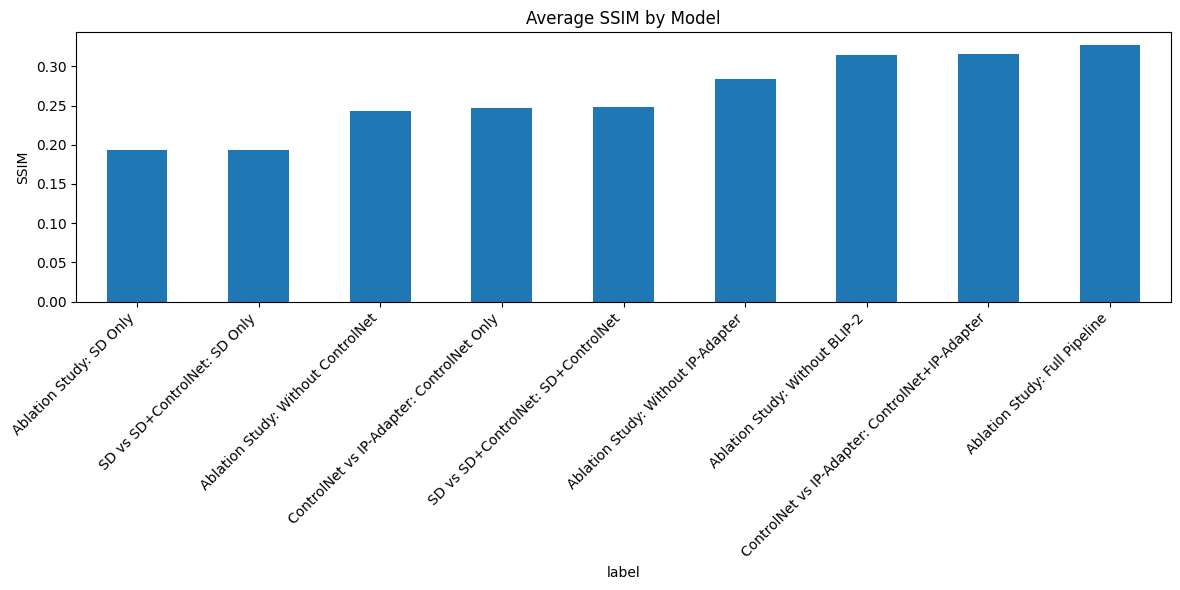

In [78]:
plt.figure(figsize=(12, 6))
summary.sort_values("ssim").plot(
    x="label",
    y="ssim",
    kind="bar",
    legend=False,
    figsize=(12, 6)
)
plt.title("Average SSIM by Model")
plt.ylabel("SSIM")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "ssim_summary.png"), dpi=300)
plt.show()

<Figure size 1200x600 with 0 Axes>

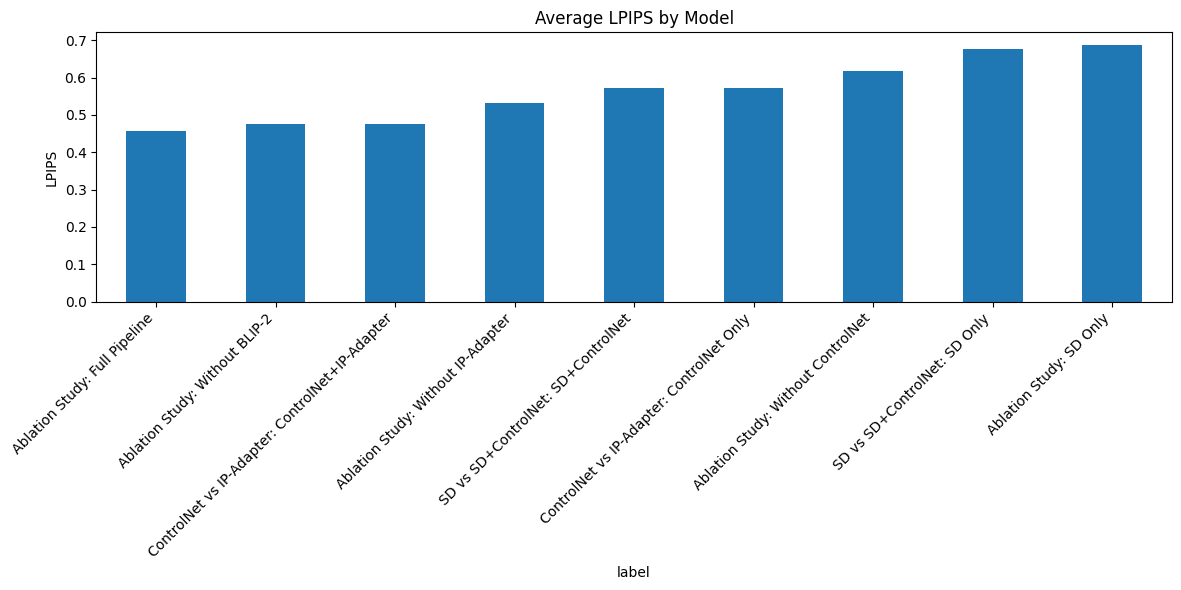

In [79]:
plt.figure(figsize=(12, 6))
summary.sort_values("lpips").plot(
    x="label",
    y="lpips",
    kind="bar",
    legend=False,
    figsize=(12, 6)
)
plt.title("Average LPIPS by Model")
plt.ylabel("LPIPS")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "lpips_summary.png"), dpi=300)
plt.show()

<Figure size 1200x600 with 0 Axes>

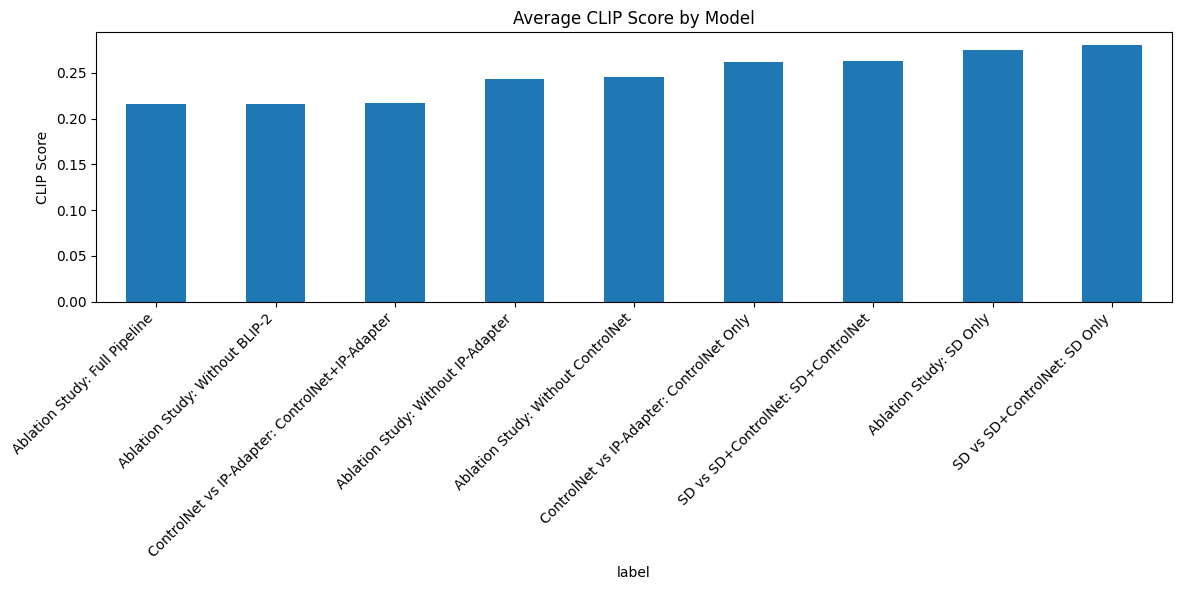

In [80]:
plt.figure(figsize=(12, 6))
summary.sort_values("clip_score").plot(
    x="label",
    y="clip_score",
    kind="bar",
    legend=False,
    figsize=(12, 6)
)
plt.title("Average CLIP Score by Model")
plt.ylabel("CLIP Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "clip_score_summary.png"), dpi=300)
plt.show()

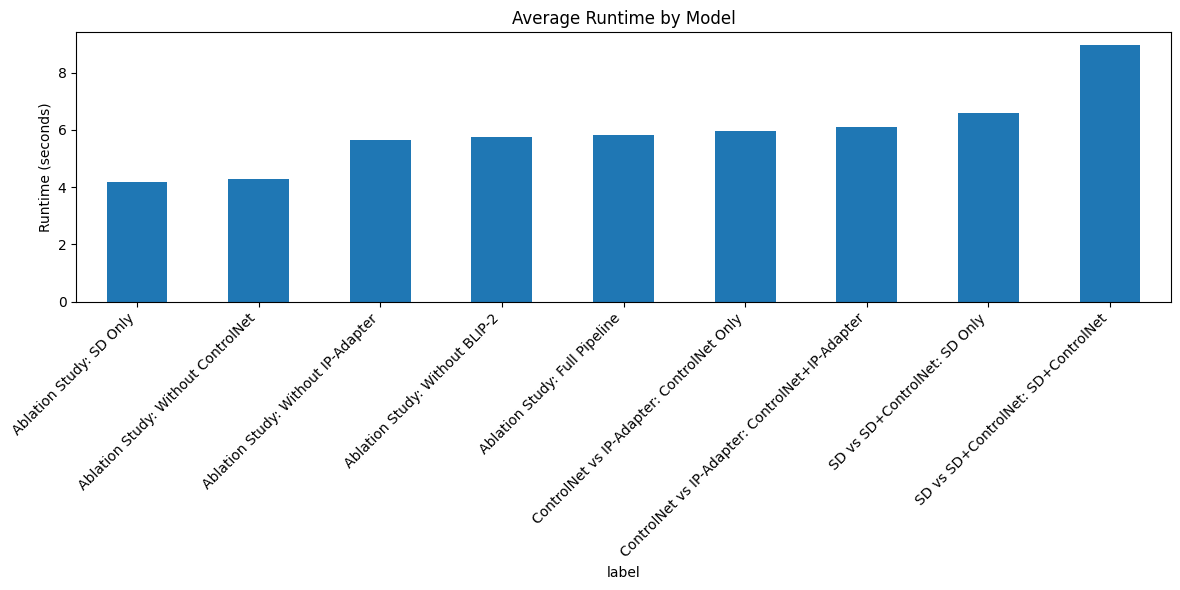

In [81]:
summary.sort_values("runtime_seconds").plot(
    x="label",
    y="runtime_seconds",
    kind="bar",
    legend=False,
    figsize=(12, 6)
)
plt.title("Average Runtime by Model")
plt.ylabel("Runtime (seconds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "runtime_summary.png"), dpi=300)
plt.show()

In [82]:
report_table = summary[[
    "label",
    "ssim",
    "lpips",
    "clip_score",
    "runtime_seconds"
]].copy()

report_table = report_table.rename(columns={
    "label": "Model / Configuration",
    "ssim": "SSIM",
    "lpips": "LPIPS",
    "clip_score": "CLIP Score",
    "runtime_seconds": "Runtime (s)"
})

report_table[["SSIM", "LPIPS", "CLIP Score", "Runtime (s)"]] = report_table[
    ["SSIM", "LPIPS", "CLIP Score", "Runtime (s)"]
].round(3)

report_table_path = os.path.join(metrics_dir, "metrics_report_table.csv")
report_table.to_csv(report_table_path, index=False)

report_table

,Model / Configuration,SSIM,LPIPS,CLIP Score,Runtime (s)
0,SD vs SD+ControlNet: SD Only,0.193,0.677,0.280,6.588
1,SD vs SD+ControlNet: SD+ControlNet,0.248,0.571,0.263,8.956
3,ControlNet vs IP-Adapter: ControlNet Only,0.247,0.571,0.262,5.948
2,ControlNet vs IP-Adapter: ControlNet+IP-Adapter,0.316,0.477,0.217,6.092
4,Ablation Study: SD Only,0.193,0.687,0.275,4.162
7,Ablation Study: Without ControlNet,0.243,0.617,0.246,4.278
8,Ablation Study: Without IP-Adapter,0.283,0.533,0.243,5.642
6,Ablation Study: Without BLIP-2,0.314,0.475,0.216,5.738
5,Ablation Study: Full Pipeline,0.327,0.457,0.216,5.802


In [83]:
print("Saved:")
print(csv_path)
print(summary_path)
print(report_table_path)
print(metrics_dir)

Saved:
/content/image-data-generation/results/metrics/metrics_summary.csv
/content/image-data-generation/results/metrics/metrics_average_summary.csv
/content/image-data-generation/results/metrics/metrics_report_table.csv
/content/image-data-generation/results/metrics


In [84]:
del lpips_model
del clip_model
del clip_processor

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared.")

GPU memory cleared.


In [86]:
from getpass import getpass
token = getpass("Paste GitHub token: ")

!git remote set-url origin https://{token}@github.com/josephzl04/image-data-generation.git
!git push origin main
!git remote set-url origin https://github.com/josephzl04/image-data-generation.git

Paste GitHub token: ··········
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 618 bytes | 618.00 KiB/s, done.
Total 6 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/josephzl04/image-data-generation.git
   a4b9f0a..c970fe3  main -> main
